# Cytosolic Small-Molecule Buffering Analysis (Cleaned)

**Purpose:** Structurally identical analysis to `small_molecule_buffer.ipynb`, rewritten for readability.

## Key design choices
- All unit conversions happen at load-time → every DataFrame column is a plain `float` in mol/L.
- **`Element` is the index** of every result DataFrame.
- **Medium is encoded by variable name** (`_minimal` / `_rich`) rather than a column, so joining is just `pd.concat([df_a, df_b], axis=1)` with no merge/groupby needed.

## Key result variables
| Variable | Shape | Description |
|---|---|---|
| `deficit_minimal`, `deficit_rich` | Element × 4 | ICP-MS total, simulation, deficit, error (all M) |
| `free_metal_minimal`, `free_metal_rich` | Element Series | Literature free-metal concentrations (M) |
| `meas_buf_minimal` | Element × 2 | Measured total buffered conc ± std (M9 media) |
| `stability` | Element × buffer | Stability constants log(β) |
| `sim_buf_minimal`, `sim_buf_rich` | buffer Series | WC simulation buffer concentrations (M) |
| `est_competition_minimal/rich` | Element Series | Estimated buffered [Metal], full competition model (M) |
| `est_simplified_minimal/rich` | Element Series | Estimated buffered [Metal], simplified model (M) |
| `results_minimal`, `results_rich` | Element × n | All results merged per condition |

## Analysis overview
1. **Deficit** = ICP-MS total − protein-bound (simulation)
2. **Competition model** – buffer free concentrations are adjusted for competition from all metals before computing buffered [Metal]
3. **Simplified model** – total buffer concentrations used directly (no cross-metal competition adjustment)

> **Note on free-metal concentrations:** Following the original analysis, Minimal-media free-metal values are used for the competition factors in *both* conditions.  Only the simulation-derived buffer concentrations differ between Minimal and Rich.

---
## 0. Setup

In [48]:
import os
from json.decoder import NaN

import dill
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from numpy.ma.core import clip
from sklearn.metrics import r2_score
from IPython.display import display

from ecoli.library.schema import bulk_name_to_idx

os.chdir(os.path.expanduser('~/dev/vEcoli'))
os.makedirs('notebooks/cofactors/buffer_figures', exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────────
AVOGADRO = 6.02214076e23                                # molecules / mol
CELL_VOLUME_FL = {"Minimal": 1.44983, "Rich": 3.073264}  # femtolitres
TARGET_METALS  = ["FE", "ZN", "MN", "CU", "MO", "NI", "CO"]

# ── Plot style ────────────────────────────────────────────────────────────────
COLORS  = {"Minimal": "steelblue", "Rich": "tomato"}
SYMBOLS = {"Minimal": "circle",    "Rich": "diamond"}

In [49]:
# ── Helper functions ──────────────────────────────────────────────────────────
def atoms_to_M(atoms: float, vol_fL: float) -> float:
    """Convert atoms/cell → mol/L (plain float, no unit objects)."""
    return float(atoms) / (AVOGADRO * vol_fL * 1e-15)

def M_to_atoms(conc:float, vol_fL: float) -> float:
    """Convert concentration in M (mol/L) to atoms/cell"""
    return conc * AVOGADRO * vol_fL * 1e-15

def load_sim(folder_path: str):
    """Load simulation output; return (bulk DataFrame, metabolism step agent)."""
    output = np.load(folder_path + '0_output.npy', allow_pickle=True).item()
    output = output['agents']['0']
    bulk   = pd.DataFrame(output['bulk'])
    with open(folder_path + 'agent_steps.pkl', 'rb') as fh:
        agent = dill.load(fh)
    metabolism = agent['ecoli-metabolism-redux-classic']
    return bulk, metabolism


def get_sim_buf_concs(
    bulk, metabolism, buffers: list[str], vol_fL: float
) -> pd.Series:
    """
    Return mean steady-state concentrations (M) for *buffers* as a Series
    indexed by molecule name.
    """
    idx        = bulk_name_to_idx(buffers, metabolism.bulk_ids)
    mean_cnts  = pd.DataFrame(bulk[idx]).mean(axis=0).values
    concs_M    = mean_cnts / (AVOGADRO * vol_fL * 1e-15)
    return pd.Series(concs_M, index=buffers, name='conc_M', dtype=float)

---
## 1. Deficit DataFrames

$$\text{deficit}_\text{M} = [\text{Metal}]_{\text{ICP}} - [\text{Metal}]_{\text{sim}}$$

Uncertainty propagated in quadrature from ICP-MS and simulation standard deviations.

In [50]:
raw = pd.read_csv('notebooks/cofactors/data/metals_plot_data.csv')
raw['Element'] = raw['Element'].str.replace('"', '').str.strip()
raw['Medium']  = raw['Medium'].str.replace('"', '').str.strip()
raw = raw[raw['Element'].isin(TARGET_METALS)].copy()

# Convert atoms/cell → M for both conditions
for cond in ['Minimal', 'Rich']:
    mask = raw['Medium'] == cond
    vol  = CELL_VOLUME_FL[cond]

    raw.loc[mask, 'icp_M']   = raw.loc[mask, 'Atoms/cell (experiment)'] / (AVOGADRO * vol * 1e-15)
    raw.loc[mask, 'sim_M']   = raw.loc[mask, 'Atoms/cell (simulation)'] / (AVOGADRO * vol * 1e-15)

    deficit_atoms = (
        raw.loc[mask, 'Atoms/cell (experiment)']
        - raw.loc[mask, 'Atoms/cell (simulation)']
    )
    deficit_err_atoms = np.sqrt(
        raw.loc[mask, 'Atoms/cell (experiment), stddev'] ** 2
        + raw.loc[mask, 'Atoms/cell (simulation), stddev'] ** 2
    )
    raw.loc[mask, 'deficit_M']     = deficit_atoms     / (AVOGADRO * vol * 1e-15)
    raw.loc[mask, 'deficit_M_err'] = deficit_err_atoms / (AVOGADRO * vol * 1e-15)

DEFICIT_COLS = ['icp_M', 'sim_M', 'deficit_M', 'deficit_M_err']

# ── Split by medium, Element as index ────────────────────────────────────────
deficit_minimal = (
    raw[raw['Medium'] == 'Minimal']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)
deficit_rich = (
    raw[raw['Medium'] == 'Rich']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)

In [51]:
print('=== deficit_minimal (Element × 4) ===')
display(deficit_minimal.style.format('{:.3e}'))

print('\n=== deficit_rich (Element × 4) ===')
display(deficit_rich.style.format('{:.3e}'))

=== deficit_minimal (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06



=== deficit_rich (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05


---
## 2. Load Simulation

In [52]:
bulk_basal, metabolism = load_sim(
    'out_cyrus/basal/metabolism_classic_1500_2026-03-24/'
)
bulk_rich, _ = load_sim(
    'out_cyrus/with_aa/metabolism_classic_1500_2026-03-24/'
)
print('Simulation loaded.  bulk_basal shape:', bulk_basal.shape,
      ' | bulk_rich shape:', bulk_rich.shape)

Simulation loaded.  bulk_basal shape: (1501, 16324)  | bulk_rich shape: (1501, 16324)


---
## 3. Buffer Constants

Columns 0–1: literature free-metal concentrations (M)  
Columns 2–3: experimentally measured *total* buffered metal concentrations ± std (M9/Minimal media)  
Columns 4+: stability constants log(β) for each ligand

In [53]:
buf_raw = pd.read_csv('notebooks/cofactors/data/buffer_constants.csv', index_col=0)
buf_raw.index.name = 'Element'

# ── Free metal concentrations (literature, M) ─────────────────────────────
free_metal_minimal = buf_raw.iloc[:, 0].astype(float).rename('free_M')  # M9 / Minimal
free_metal_rich    = buf_raw.iloc[:, 1].astype(float).rename('free_M')  # LB / Rich

# ── Measured total buffered concentrations (M9 only) ──────────────────────
# divide by 2 to account for 50% cytosol volume of the measurements
meas_buf_minimal = buf_raw.iloc[:, 2:4].astype(float).copy() / 2
meas_buf_minimal.columns = ['measured_M', 'measured_std_M']

# ── Stability constants log(β): Element × buffer ──────────────────────────
stability = buf_raw.iloc[:, 4:].astype(float).copy()
stability_ub = stability + 1
stability_lb = stability - 1


# ── Look-up dicts (same structure as original) ────────────────────────────
buffer_to_metal_ub: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_ub: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}
buffer_to_metal_lb: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_lb: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}

for buf in stability.columns:
    row_ub = stability_ub[buf].dropna()
    row_lb = stability_lb[buf].dropna()
    if not row_ub.empty:
        buffer_to_metal_ub[buf] = row_ub.to_dict()
        buffer_to_metal_lb[buf] = row_lb.to_dict()

for buf, metals_dict in buffer_to_metal_ub.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_ub.setdefault(metal, {})[buf] = logbeta

for buf, metals_dict in buffer_to_metal_lb.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_lb.setdefault(metal, {})[buf] = logbeta

ALL_BUFFERS = list(buffer_to_metal_ub.keys())
ALL_METALS  = list(free_metal_minimal.index)

In [54]:
print('=== free_metal_minimal (Element Series, M) ===')
display(free_metal_minimal.to_frame().style.format('{:.3e}'))

print('\n=== meas_buf_minimal (Element × 2, M) ===')
display(meas_buf_minimal.style.format('{:.3e}'))

print('\n=== stability (Element × buffer, log β) ===')
display(stability)

print('\nBuffers with stability data:', ALL_BUFFERS)

=== free_metal_minimal (Element Series, M) ===


,free_M
Element,
MN,2.080e-06
FE,6.180e-08
CO,2.420e-10
NI,2.560e-12
CU,1.460e-20
ZN,1.040e-11



=== meas_buf_minimal (Element × 2, M) ===


,measured_M,measured_std_M
Element,,
MN,7.000e-07,3.500e-07
FE,4.000e-05,1.000e-05
CO,nan,nan
NI,7.500e-06,1.000e-06
CU,5.000e-06,1.000e-06
ZN,6.500e-06,1.500e-06



=== stability (Element × buffer, log β) ===


,GLUTATHIONE[c],CYS[c],HIS[c],OXIDIZED-GLUTATHIONE[c],L-ASPARTATE[c],CIT[c],ATP[c],TRP[c],MET[c],L-ALPHA-ALANINE[c],LEU[c],VAL[c],GLY[c]
Element,,,,,,,,,,,,,
MN,2.70,NaN,3.914872,NaN,3.91,3.42160,5.17,3.340000,3.59,3.24,2.150,2.84,3.20
FE,5.40,6.2,5.883093,NaN,NaN,4.49000,5.18,NaN,NaN,7.30,NaN,6.80,7.80
CO,NaN,NaN,7.442480,NaN,6.69,4.54365,5.21,4.340000,3.85,8.55,8.160,8.24,9.10
NI,11.15,NaN,9.200000,9.08,7.00,5.07555,5.32,5.756636,NaN,10.66,10.180,NaN,11.15
CU,NaN,NaN,NaN,NaN,8.78,15.03000,6.83,15.560000,7.96,14.94,15.174,14.91,15.63
ZN,8.31,NaN,7.068186,7.60,5.35,4.56427,5.52,5.000000,4.46,5.16,4.920,5.00,5.16



Buffers with stability data: ['GLUTATHIONE[c]', 'CYS[c]', 'HIS[c]', 'OXIDIZED-GLUTATHIONE[c]', 'L-ASPARTATE[c]', 'CIT[c]', 'ATP[c]', 'TRP[c]', 'MET[c]', 'L-ALPHA-ALANINE[c]', 'LEU[c]', 'VAL[c]', 'GLY[c]']


---
## 4. Simulation Buffer Concentrations

Mean steady-state concentrations across all simulation time-steps, converted to mol/L.

In [55]:
sim_buf_minimal = get_sim_buf_concs(
    bulk_basal, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Minimal']
)
sim_buf_rich = get_sim_buf_concs(
    bulk_rich, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Rich']
)

# ── Display side by side ───────────────────────────────────────────────────
sim_buf_display = pd.concat(
    [sim_buf_minimal.rename('Minimal'), sim_buf_rich.rename('Rich')], axis=1
)
print('=== sim_buf_minimal / sim_buf_rich (buffer Series, M) ===')
display(sim_buf_display.style.format('{:.3e}'))

=== sim_buf_minimal / sim_buf_rich (buffer Series, M) ===


,Minimal,Rich
GLUTATHIONE[c],9.790e-03,1.199e-02
CYS[c],1.807e-05,4.426e-05
HIS[c],6.100e-05,1.494e-04
OXIDIZED-GLUTATHIONE[c],1.122e-03,1.374e-03
L-ASPARTATE[c],2.109e-03,5.166e-03
CIT[c],1.528e-03,1.871e-03
ATP[c],8.017e-03,9.820e-03
TRP[c],1.807e-05,3.754e-04
MET[c],6.757e-05,1.655e-04
L-ALPHA-ALANINE[c],9.288e-04,2.275e-03


---
## 5. Approach 1 – Competition Model

**Step 1** – free buffer concentration (accounting for metal competition)

$$[L_\text{free}] = \frac{[L_\text{total}]}{1 + \sum_M K_{A,M} \cdot [M_\text{free}]}$$

**Step 2** – total buffered metal concentration

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{free}]\right)$$

> **Note:** Following the original analysis, `free_metal_minimal` is used for the competition factor in *both* conditions.  Only the simulation-derived buffer concentrations (`sim_buf_minimal` vs `sim_buf_rich`) differ.

In [56]:
def estimate_buffered_competition(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
    buffer_to_metal: dict,
) -> pd.Series:
    """
    Full competition model.

    Parameters
    ----------
    metals        : metals to compute (must be in free_metal.index)
    free_metal    : Series[Element → [M]free], literature values
    sim_buf       : Series[buffer_mol → conc_M], from simulation
    metal_to_buffer, buffer_to_metal : look-up dicts with log β values

    Returns
    -------
    Series[Element → estimated total buffered conc (M)]
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    stoichiometry = {("CU", "TRP[c]"): 2,
                     ("NI", "GLUTATHIONE[c]"): 2,
                     ("CU", "GLY[c]"): 2,
                     ("NI", "GLY[c]"): 2,
                     ("CO", "GLY[c]"): 2,
                     ("FE", "GLY[c]"): 2,
                     ("CU", "L-ALPHA-ALANINE[c]"): 2,
                     ("NI", "L-ALPHA-ALANINE[c]"): 2,
                     ("CO", "L-ALPHA-ALANINE[c]"): 2,
                     ("FE", "L-ALPHA-ALANINE[c]"): 2,
                     ("CU", "VAL[c]"): 2,
                     ("CO", "VAL[c]"): 2,
                     ("FE", "VAL[c]"): 2,
                     ("CU", "LEU[c]"): 2,
                     ("NI", "LEU[c]"): 2,
                     ("CO", "LEU[c]"): 2,
                     ("CU", "CIT[c]"): 2,
                     ("CIT[c]", "CU"): 2
                     }


    # Step 1: free buffer concentrations (all buffers)
    free_buf: dict[str, float] = {}
    for buf, metals_logbeta in buffer_to_metal.items():
        total = sim_buf_d.get(buf, 0.0)
        comp  = sum(
            10 ** lb * stoichiometry.get((m, buf), 1) * free_metal_d.get(m, 0.0) ** stoichiometry.get((buf, m), 1)
            for m, lb in metals_logbeta.items()
        )
        free_buf[buf] = total / (1 + comp)

    # Step 2: total buffered metal for each element
    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * stoichiometry.get((buf, metal), 1)* free_buf.get(buf, 0.0) ** stoichiometry.get((metal, buf), 1)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_competition_M', dtype=float)

In [57]:
est_competition_minimal_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_lb, buffer_to_metal_lb
)
est_competition_minimal_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_ub, buffer_to_metal_ub
)
est_competition_rich_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_rich,    metal_to_buffer_lb, buffer_to_metal_lb  # note: Minimal free-metal
)
est_competition_rich_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_rich,    metal_to_buffer_ub, buffer_to_metal_ub  # note: Minimal free-metal
)

print('=== est_competition_minimal / est_competition_rich (Element Series, M) ===')
display(
    pd.concat([
        est_competition_minimal_lb.rename('Minimal Lower Bound'),
        est_competition_minimal_ub.rename('Minimal Upper Bound'),
        est_competition_rich_lb.rename('Rich Lower Bound'),
        est_competition_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_competition_minimal / est_competition_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MN,2.471e-04,6.322e-03,3.074e-04,8.146e-03
FE,2.233e-05,4.129e-04,2.835e-05,5.370e-04
CO,3.291e-07,2.437e-05,8.012e-07,5.882e-05
NI,3.388e-06,4.014e-05,5.067e-06,5.299e-05
CU,8.514e-12,6.340e-10,2.475e-11,1.119e-09
ZN,1.986e-06,2.934e-05,2.434e-06,3.605e-05


---
## 6. Approach 2 – Simplified Model

Same as Approach 1 but the free buffer concentration equals the total simulation concentration (no cross-metal competition correction for ligand occupancy):

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{total}]\right)$$

In [58]:
def estimate_buffered_simplified(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
) -> pd.Series:
    """
    Simplified model: uses total (not free) buffer concentrations.
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    stoichiometry = {("CU", "TRP[c]"): 2,
                     ("NI", "GLUTATHIONE[c]"): 2,
                     ("CU", "GLY[c]"): 2,
                     ("NI", "GLY[c]"): 2,
                     ("CO", "GLY[c]"): 2,
                     ("FE", "GLY[c]"): 2,
                     ("CU", "L-ALPHA-ALANINE[c]"): 2,
                     ("NI", "L-ALPHA-ALANINE[c]"): 2,
                     ("CO", "L-ALPHA-ALANINE[c]"): 2,
                     ("FE", "L-ALPHA-ALANINE[c]"): 2,
                     ("CU", "VAL[c]"): 2,
                     ("CO", "VAL[c]"): 2,
                     ("FE", "VAL[c]"): 2,
                     ("CU", "LEU[c]"): 2,
                     ("NI", "LEU[c]"): 2,
                     ("CO", "LEU[c]"): 2,
                     ("CU", "CIT[c]"): 2,
                     ("CIT[c]", "CU"): 2
                     }

    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * stoichiometry.get((buf, metal), 1) * sim_buf_d.get(buf, 0.0) ** stoichiometry.get((metal, buf), 1)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_simplified_M', dtype=float)

In [59]:
est_simplified_minimal_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_lb
)
est_simplified_minimal_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_ub
)
est_simplified_rich_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_rich, metal_to_buffer_lb
)
est_simplified_rich_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_rich, metal_to_buffer_ub
)

print('=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===')
display(
    pd.concat([
        est_simplified_minimal_lb.rename('Minimal Lower Bound'),
        est_simplified_minimal_ub.rename('Minimal Upper Bound'),
        est_simplified_rich_lb.rename('Rich Lower Bound'),
        est_simplified_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MN,2.549e-04,2.528e-02,3.172e-04,3.151e-02
FE,2.373e-05,2.367e-03,3.064e-05,3.058e-03
CO,3.398e-07,3.396e-05,8.582e-07,8.580e-05
NI,3.862e-06,3.862e-04,5.828e-06,5.828e-04
CU,1.019e-11,1.019e-09,3.495e-11,3.495e-09
ZN,2.130e-06,2.130e-04,2.611e-06,2.611e-04


---
## 7. Combined Results Tables

Because every DataFrame is Element-indexed, assembling the full results is a single `pd.concat` — no merge, no groupby.

In [60]:
results_minimal = pd.concat(
    [
        deficit_minimal,
        meas_buf_minimal,
        est_competition_minimal_lb,
        est_competition_minimal_ub,
        est_simplified_minimal_lb,
        est_simplified_minimal_ub,
        free_metal_minimal,
    ],
    axis=1,
)

results_rich = pd.concat(
    [
        deficit_rich,
        est_competition_rich_lb,
        est_competition_rich_ub,
        est_simplified_rich_lb,
        est_simplified_rich_ub,
        free_metal_minimal.rename('free_M_lit'),  # Minimal free-metal used for both
    ],
    axis=1,
)

print('=== results_minimal ===')
display(results_minimal.style.format('{:.3e}'))

print('\n=== results_rich ===')
display(results_rich.style.format('{:.3e}'))

=== results_minimal ===


,icp_M,sim_M,deficit_M,deficit_M_err,measured_M,measured_std_M,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05,4.000e-05,1.000e-05,2.233e-05,4.129e-04,2.373e-05,2.367e-03,6.180e-08
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06,5.000e-06,1.000e-06,8.514e-12,6.340e-10,1.019e-11,1.019e-09,1.460e-20
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06,nan,nan,3.291e-07,2.437e-05,3.398e-07,3.396e-05,2.420e-10
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06,7.500e-06,1.000e-06,3.388e-06,4.014e-05,3.862e-06,3.862e-04,2.560e-12
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05,6.500e-06,1.500e-06,1.986e-06,2.934e-05,2.130e-06,2.130e-04,1.040e-11
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06,nan,nan,nan,nan,nan,nan,nan
MN,nan,nan,nan,nan,7.000e-07,3.500e-07,2.471e-04,6.322e-03,2.549e-04,2.528e-02,2.080e-06



=== results_rich ===


,icp_M,sim_M,deficit_M,deficit_M_err,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M_lit
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05,2.475e-11,1.119e-09,3.495e-11,3.495e-09,1.460e-20
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07,nan,nan,nan,nan,nan
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07,5.067e-06,5.299e-05,5.828e-06,5.828e-04,2.560e-12
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05,2.434e-06,3.605e-05,2.611e-06,2.611e-04,1.040e-11
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08,8.012e-07,5.882e-05,8.582e-07,8.580e-05,2.420e-10
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06,3.074e-04,8.146e-03,3.172e-04,3.151e-02,2.080e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05,2.835e-05,5.370e-04,3.064e-05,3.058e-03,6.180e-08


---
## 8. Plots

### Helper: build long-form DataFrame for plotting (positive deficits only)

In [61]:
def build_plot_df(
    est_minimal_lb: pd.Series,
    est_minimal_ub: pd.Series,
    est_rich_lb: pd.Series,
    est_rich_ub: pd.Series,
    deficit_minimal: pd.DataFrame,
    deficit_rich: pd.DataFrame,
    positive_only: bool = True,
) -> pd.DataFrame:
    """
    Merge lb/ub buffered estimates with deficits into a long-form DataFrame.

    Columns: Medium, Element, est_buf_lb_M, est_buf_ub_M,
             est_buf_center_M, deficit_M, deficit_M_err
    """
    rows = []
    for cond, est_lb, est_ub, deficit_df in [
        ('Minimal', est_minimal_lb, est_minimal_ub, deficit_minimal),
        ('Rich',    est_rich_lb,    est_rich_ub,    deficit_rich),
    ]:
        for element in est_lb.index:
            if element not in deficit_df.index:
                continue
            deficit_val = deficit_df.loc[element, 'deficit_M']
            deficit_err = deficit_df.loc[element, 'deficit_M_err']
            if positive_only and deficit_val <= 0:
                continue
            lb = float(est_lb[element])
            ub = float(est_ub[element])
            rows.append({
                'Medium':            cond,
                'Element':           element,
                'est_buf_lb_M':      lb,
                'est_buf_ub_M':      ub,
                'est_buf_center_M':  (lb + ub) / 2,
                'deficit_M':         float(deficit_val),
                'deficit_M_err':     float(deficit_err),
            })
    return pd.DataFrame(rows)

### Plot 1 – Competition model: estimated buffered [Metal] vs. Estimated deficit

In [62]:
import polars as pl
import altair as alt

plot_df_comp = build_plot_df(
    est_competition_minimal_lb, est_competition_minimal_ub,
    est_competition_rich_lb,    est_competition_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

# ── Log-axis label expression (10^n with Unicode superscripts) ────────────────
_log_label_unicode = (
    "datum.value > 0 ? '10' + "
    "replace(replace(replace(replace(replace(replace("
    "replace(replace(replace(replace(replace('' + "
    "round(log(datum.value)/LN10), '-','⁻'),'0','⁰'),'1','¹'),'2','²')"
    ",'3','³'),'4','⁴'),'5','⁵'),'6','⁶'),'7','⁷'),'8','⁸'),'9','⁹') : '0'"
)

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_df = pl.DataFrame({"v": [1e-6, 1e6]})  # for reference line y=x

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=""),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=150, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Competition Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_competition.svg')
chart

alt.LayerChart(...)

### Plot 2 – Simplified model: estimated buffered [Metal] vs. M-M deficit

In [63]:
plot_df_simp = build_plot_df(
    est_simplified_minimal_lb, est_simplified_minimal_ub,
    est_simplified_rich_lb,    est_simplified_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_simp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=""),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=150, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Simplified Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_simplified.svg')
chart

alt.LayerChart(...)

### Plot 3 – Overlay: competition vs. simplified, with shift arrows

In [64]:
def prep_model_df(plot_df_pd, model_label: str) -> pl.DataFrame:
    return (
        pl.from_pandas(plot_df_pd)
        .with_columns([
            (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
            (pl.col("deficit_M")        * 1e6).alias("y_uM"),
            pl.lit(model_label).alias("model"),
        ])
        .filter((pl.col("x_uM") > 0) & (pl.col("y_uM") > 0))
    )

df_simp = prep_model_df(plot_df_simp, "simplified")
df_comp = prep_model_df(plot_df_comp, "competition")

df_simp = df_simp.with_columns(
    pl.concat_str([pl.col("Medium"), pl.lit(" (simplified)")]).alias("medium_model")
)
df_comp = df_comp.with_columns(
    pl.concat_str([pl.col("Medium"), pl.lit(" (competition)")]).alias("medium_model")
)

# ── Scales for the four-way legend ───────────────────────────────────────────
DOMAIN = [
    "Minimal (simplified)", "Minimal (competition)",
    "Rich (simplified)",    "Rich (competition)",
]
COLOR_RANGE = ["steelblue", "steelblue", "tomato", "tomato"]
SHAPE_RANGE = ["circle",    "circle",    "diamond", "diamond"]
OPACITY_RANGE = [0.4, 1.0, 0.4, 1.0]   # simplified = faded, competition = solid

color_scale4 = alt.Scale(domain=DOMAIN, range=COLOR_RANGE)
shape_scale4 = alt.Scale(domain=DOMAIN, range=SHAPE_RANGE)

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

legend_cfg = alt.Legend(title="Medium / Model")
# Arrow table: one row per (Medium, Element) pair
df_arrows = (
    df_simp.join(df_comp, on=["Medium", "Element"], suffix="_comp")
    .filter(
        (pl.col("x_uM_comp") > 0) & (pl.col("y_uM_comp") > 0) &
        ((pl.col("x_uM_comp") - pl.col("x_uM")).abs() +
         (pl.col("y_uM_comp") - pl.col("y_uM")).abs() > 1e-10)
    )
)

# Compute arrowhead angle in log10 space — in Vega 0°=up, clockwise positive
x0 = df_arrows["x_uM"].to_numpy()
y0 = df_arrows["y_uM"].to_numpy()
x1 = df_arrows["x_uM_comp"].to_numpy()
y1 = df_arrows["y_uM_comp"].to_numpy()
math_angle = np.degrees(np.arctan2(np.log10(y1/y0), np.log10(x1/x0)))
vega_angle  = 90 - math_angle   # convert: math 0°=right → Vega 0°=up

df_arrows = df_arrows.with_columns(
    pl.Series("arrow_angle_deg", vega_angle)
)

x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
color_scale = alt.Scale(
    domain=["Minimal","Rich"],
    range=["steelblue","tomato"]
)
shape_scale = alt.Scale(
    domain=["Minimal","Rich"],
    range=["circle","diamond"]
)

# 1. y = x reference
ref_line = (
    alt.Chart(pl.DataFrame({"v": [1e-6, 1e6]}))
    .mark_line(strokeDash=[4,4], color="gray")
    .encode(
        x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
        y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
    )
)

# 2. Simplified points — semi-transparent
simp_pts = (
    alt.Chart(df_simp)
    .mark_point(filled=True, size=150, stroke="black", strokeWidth=1)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale, title="Modeled Buffered [Metal] [µmol/L]"),
        y=alt.Y("y_uM:Q", scale=y_scale, title="Estimated Deficit [µmol/L]"),
        color=alt.Color("medium_model:N", scale=color_scale4, legend=legend_cfg),
        shape=alt.Shape("medium_model:N", scale=shape_scale4, legend=legend_cfg),
        opacity=alt.OpacityValue(0.45),
    )
)


# 3. Competition points — opaque, with labels
comp_pts = (
    alt.Chart(df_comp)
    .mark_point(filled=True, size=150, stroke="black", strokeWidth=1)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale),
        y=alt.Y("y_uM:Q", scale=y_scale),
        color=alt.Color("medium_model:N", scale=color_scale4, legend=legend_cfg),
        shape=alt.Shape("medium_model:N", scale=shape_scale4, legend=legend_cfg),
        opacity=alt.OpacityValue(1.0),
    )
)

comp_labels = (
    alt.Chart(df_comp)
    .mark_text(dx=8, dy=-8, fontSize=11)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale),
        y=alt.Y("y_uM:Q", scale=y_scale),
        text="Element:N",
    )
)

# 4a. Arrow lines (simplified → competition)
arrow_lines = (
    alt.Chart(df_arrows)
    .mark_rule(color="gray", opacity=0.6, strokeWidth=1.2)
    .encode(
        x=alt.X( "x_uM:Q",      scale=x_scale),
        y=alt.Y( "y_uM:Q",      scale=y_scale),
        x2=alt.X2("x_uM_comp:Q"),
        y2=alt.Y2("y_uM_comp:Q"),
    )
)

# 4b. Arrowheads at the tip (competition end)
arrow_heads = (
    alt.Chart(df_arrows)
    .mark_point(shape="triangle", filled=True, size=20,
                color="darkgray", opacity=0.8)
    .encode(
        x=alt.X("x_uM_comp:Q", scale=x_scale),
        y=alt.Y("y_uM_comp:Q", scale=y_scale),
        angle=alt.Angle("arrow_angle_deg:Q",
                        scale=alt.Scale(domain=[0,360], range=[0,360])),
    )
)

chart3 = (
    ref_line +  simp_pts +  comp_pts + arrow_lines + arrow_heads + comp_labels
).properties(
    width=600, height=480,
    title="Overlay: Competition vs. Simplified Buffering Models"
).configure_axis(gridColor="#f3f6fa")
chart3.save("notebooks/cofactors/buffer_figures/two_models_comparison.svg")
chart3

alt.LayerChart(...)

### Plot 4 – Measured buffered [Metal] vs. deficit figure 1C, Minimal media

x-axis: experimentally measured total buffered concentration (ICP-MS, M9)  
y-axis: Deficit adjusted so that metals whose deficit is negative but within error are shown at a floor of 1 µM

In [65]:
display(df_p4_clean.style.format('{:.3e}'))

,deficit_M,deficit_M_err,measured_M,measured_std_M
CU,1.000e-06,1.512e-06,5.000e-06,1.000e-06
NI,3.546e-06,1.154e-06,7.500e-06,1.000e-06
ZN,1.000e-06,6.533e-05,6.500e-06,1.500e-06


In [66]:
# Build df_plot4: Minimal only, adjusted deficit floor
df_p4 = results_minimal[['deficit_M', 'deficit_M_err', 'measured_M', 'measured_std_M']].copy()

# Apply floor: if deficit is negative but within error → set to 1 µM
neg_but_possible = (df_p4["deficit_M"] < 0) & (
    df_p4["deficit_M"] + df_p4["deficit_M_err"] > 0
)
df_p4.loc[neg_but_possible, "deficit_M"] = 1e-6

df_p4_clean = df_p4.dropna(subset=["measured_M", "deficit_M"]).copy()
df_p4_clean = df_p4_clean[df_p4_clean["deficit_M"] > 0]

x     = df_p4_clean["measured_M"].astype(float) * 1e6
y     = df_p4_clean["deficit_M"].astype(float) * 1e6
x_err = df_p4_clean["measured_std_M"].fillna(0).astype(float) * 1e6
y_err = df_p4_clean["deficit_M_err"].astype(float) * 1e6

mask = (x > 0) & (y > 0)
r2   = r2_score(np.log10(y[mask]), np.log10(x[mask]))

ref_range = np.logspace(-4, 6, 100)

fig4 = go.Figure()
fig4.add_trace(go.Scatter(
    x=ref_range, y=ref_range,
    mode='lines', name='y = x',
    line=dict(color='gray', dash='dash', width=1.5),
))
fig4.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers+text',
    name='Minimal',
    text=df_p4_clean.index.tolist(),
    textposition='top center',
    marker=dict(size=10, color='steelblue', line=dict(width=1, color='black')),
    error_x=dict(type="data", array=x_err, visible=True, color="steelblue", thickness=1.5),
))
fig4.add_annotation(
    x=0.05, y=0.95, xref="paper", yref="paper",
    text=f'R² = {r2:.3f}', showarrow=False,
    font=dict(size=14), bgcolor='white', bordercolor='gray', borderwidth=1,
)
fig4.update_layout(
    title='Measured vs. Deficit Figure 1C – Minimal Media',
    xaxis=dict(title='Measured Buffered [Metal] Concentration [µmol/L]', type='log', range=[-2, 3]),
    yaxis=dict(title='Estimated Deficit [µmol/L]', type='log', range=[-2, 3]),
    template='plotly_white', width=650, height=600,
)
fig4.show()

### Plot 5 – Measured buffered [Metal] concentration vs. Deficit Figure 1C (absolute value, Minimal)

In [67]:
# All metals with measured buffered data (CO is NaN → dropped automatically)
df_p5 = results_minimal[[
    'deficit_M', 'deficit_M_err',
    'measured_M', 'measured_std_M',
]].dropna(subset=['measured_M']).copy()

x_5     = abs(df_p5["measured_M"].astype(float).values * 1e6)
y_5     = abs(df_p5["deficit_M"].astype(float).values * 1e6)
x_5_err = df_p5["measured_std_M"].fillna(0).astype(float).values * 1e6
y_5_err = df_p5["deficit_M_err"].astype(float).values * 1e6

x_pos_5 = x_5[x_5 > 0]
x_ref_5 = np.logspace(np.log10(x_pos_5.min()) - 0.5, np.log10(x_pos_5.max()) + 0.5, 100)

ref_range = np.logspace(-4, 6, 100)

fig5 = go.Figure()
fig5.add_trace(go.Scatter(
    x=ref_range, y=ref_range,
    mode='lines', name='y=x',
    line=dict(color='gray', dash='dash', width=1.5),
))
fig5.add_trace(go.Scatter(
    x=x_5, y=y_5,
    mode='markers+text',
    name='Minimal',
    text=df_p5.index.tolist(),
    textposition='top center',
    marker=dict(size=12, color='steelblue', symbol='circle',
                line=dict(width=1, color='black')),
    error_x=dict(type="data", array=x_5_err.tolist(), visible=True,
                 color="steelblue", thickness=1.5),
    error_y=dict(type="data", array=y_5_err.tolist(), visible=True,
                 color="steelblue", thickness=1.5),
))
fig5.update_layout(
    title='Measured Buffered Concentration vs. Deficit Fig1C (Minimal Media)',
    xaxis=dict(title='Measured Buffered [Metal] Concentration [µmol/L]', type='log', range = [-3, 3]),
    yaxis=dict(title='Deficit Fig 1C [µmol/L]', type='log', range = [-3, 3]),
    template='plotly_white', width=650, height=550,
    legend=dict(title='Medium'),
)
fig5.show()

### Plot 6– Measured buffered [Metal] concentration vs. Modeled Deficit (absolute value, Minimal)

In [74]:
results_minimal

,icp_M,sim_M,deficit_M,deficit_M_err,measured_M,measured_std_M,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M
FE,2.061353e-04,3.064893e-04,-1.003540e-04,0.000034,4.000000e-05,1.000000e-05,2.232638e-05,4.129482e-04,2.372956e-05,2.366837e-03,6.180000e-08
CU,8.991644e-06,9.728729e-06,-7.370850e-07,0.000002,5.000000e-06,1.000000e-06,8.513557e-12,6.340320e-10,1.019211e-11,1.019211e-09,1.460000e-20
CO,5.956603e-07,0.000000e+00,5.956603e-07,0.000001,NaN,NaN,3.291222e-07,2.437319e-05,3.397963e-07,3.395567e-05,2.420000e-10
NI,4.329449e-06,7.835023e-07,3.545947e-06,0.000001,7.500000e-06,1.000000e-06,3.388215e-06,4.013896e-05,3.861880e-06,3.861878e-04,2.560000e-12
ZN,2.288471e-04,2.462680e-04,-1.742089e-05,0.000065,6.500000e-06,1.500000e-06,1.985904e-06,2.933781e-05,2.129664e-06,2.129654e-04,1.040000e-11
MO,4.562235e-06,2.508332e-06,2.053903e-06,0.000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MN,NaN,NaN,NaN,NaN,7.000000e-07,3.500000e-07,2.470516e-04,6.321919e-03,2.548694e-04,2.528102e-02,2.080000e-06


In [71]:
# All metals with measured buffered data (CO is NaN → dropped automatically)
df_p6 = results_minimal[[
    'est_competition_M',
    'measured_M', 'measured_std_M',
]].dropna(subset=['measured_M','est_competition_M']).copy()

x_5     = abs(df_p6["measured_M"].astype(float).values * 1e6)
y_5     = abs(df_p6["est_competition_M"].astype(float).values * 1e6)
x_5_err = df_p6["measured_std_M"].fillna(0).astype(float).values * 1e6

x_pos_5 = x_5[x_5 > 0]
x_ref_5 = np.logspace(np.log10(x_pos_5.min()) - 0.5, np.log10(x_pos_5.max()) + 0.5, 100)

ref_range = np.logspace(-6, 6, 100)

fig6 = go.Figure()
fig6.add_trace(go.Scatter(
    x=ref_range, y=ref_range,
    mode='lines', name='y=x',
    line=dict(color='gray', dash='dash', width=1.5),
))
fig6.add_trace(go.Scatter(
    x=x_5, y=y_5,
    mode='markers+text',
    name='Minimal',
    text=df_p5.index.tolist(),
    textposition='top center',
    marker=dict(size=12, color='steelblue', symbol='circle',
                line=dict(width=1, color='black')),
    error_x=dict(type="data", array=x_5_err.tolist(), visible=True,
                 color="steelblue", thickness=1.5),
))
fig6.update_layout(
    title='Measured Buffered Concentration vs. Modeled Deficit (Minimal Media)',
    xaxis=dict(title='Measured Buffered [Metal] Concentration [µmol/L]', type='log', range = [-6, 3], dtick =1),
    yaxis=dict(title='Modeled Deficit [µmol/L]', type='log', range = [-6, 3], dtick =1),
    template='plotly_white', width=650, height=550,
    legend=dict(title='Medium'),
)
fig6.show(renderer='browser')
# fig6.write_image(
#     'notebooks/cofactors/buffer_figures/measured_buffer_vs_modeled_deficit_minimal.svg', scale=2)

### Plot 7 – Grouped bar chart: Deficit Figure 1C vs. modeled vs. measured buffered concentration (Minimal Media)

Three bars per metal element:
- **Deficit** (ICP-MS total − simulation): signed value with propagated error
- **Modeled** (competition model estimated total buffered concentration): no uncertainty available
- **Measured** (experimentally measured total buffered concentration): error from std

Metals without measured data (MO, V, CR) show only the first two bars.

In [27]:
# ── Assemble bar-chart table from results_minimal ───────────────────────────
# Only metals present in deficit_minimal; measured column has NaN where no data
elements = results_minimal.index.tolist()

bar_df = pd.DataFrame({
    'element':         elements,
    'deficit_uM':      results_minimal['deficit_M']       * 1e6,
    'deficit_err_uM':  results_minimal['deficit_M_err']   * 1e6,
    'model_uM_lb':        est_competition_minimal_lb.reindex(elements) * 1e6,
    'model_uM_ub':        est_competition_minimal_ub.reindex(elements) * 1e6,
    'measured_uM':     meas_buf_minimal['measured_M'].reindex(elements) * 1e6,
    'measured_err_uM': meas_buf_minimal['measured_std_M'].reindex(elements) * 1e6,
}).set_index("element")

fig7 = go.Figure()

# Bar 1 – M-M Deficit (ICP − simulation, signed: negative = surplus)
fig7.add_trace(go.Bar(
    name='Deficit (Fig 1C)',
    x=bar_df.index,
    y=bar_df['deficit_uM'],
    error_y=dict(
        type='data',
        array=bar_df['deficit_err_uM'].values,
        visible=True,
        color="steelblue",
        thickness=1.5,
    ),
    marker_color='steelblue',
    marker_line=dict(width=1, color='black'),
))

# Bar 2 – Competition model estimate (no error available)
fig7.add_trace(go.Bar(
    name='Modeled Buffered w/ Competition',
    x=bar_df.index,
    y=0.5*(bar_df['model_uM_lb'] + bar_df['model_uM_ub']),
    marker_color='tomato',
    marker_line=dict(width=1, color='black'),
))

# Bar 3 – Experimentally measured total buffered concentration
fig7.add_trace(go.Bar(
    name='Experimentally Measured Buffered Concentration',
    x=bar_df.index,
    y=bar_df['measured_uM'],
    error_y=dict(
        type='data',
        array=bar_df['measured_err_uM'].fillna(0).values,
        visible=True,
        color="seagreen",
        thickness=1.5,
    ),
    marker_color='seagreen',
    marker_line=dict(width=1, color='black'),
))

fig7.update_layout(
    barmode='group',
    title='Decifit Fig 1C, Measured, and Modeled Buffer (Minimal Media)',
    xaxis=dict(
        title='Metal Element',
        tickfont=dict(size=13),
    ),
    yaxis=dict(
        title='Concentration [µmol/L]',
        zeroline=True,
        zerolinewidth=1.5,
        zerolinecolor='black',
        type='log',
    ),
    template='plotly_white',
    width=900,
    height=550,
    legend=dict(title='Method', orientation='v'),
    bargap=0.25,
    bargroupgap=0.05,
)
fig7.show(renderer='browser')

### Plot 8 – Categorical scatter: Deficit Figure 1C vs. modeled vs. measured buffered concentration (Minimal Media)

Same data as Plot 7, but displayed as a **categorical dot plot with std-error bars** instead of grouped bars.
Each element on the x-axis has three offset points:
- **Deficit (Fig 1C)** – ICP-MS total − simulation ± propagated error
- **Modeled Buffered** – competition-model mid-point ± half the lb/ub range
- **Measured Buffered** – experimentally measured ± std

Elements without measured data (MO, V, CR, …) show only the first two points.

In [30]:
DOMAIN_MIN = 1e-7


df_wide = pl.from_pandas(bar_df.reset_index()).with_columns([
    (0.5 * (pl.col("model_uM_lb") + pl.col("model_uM_ub"))).alias("model_mid_uM"),
    (0.5 * (pl.col("model_uM_ub") - pl.col("model_uM_lb")).abs()).alias("model_err_uM"),
])

_series_labels = {
    "Deficit (Fig 1C)":  ("deficit_uM",   "deficit_err_uM"),
    "Modeled Buffered":  ("model_mid_uM", "model_err_uM"),
    "Measured Buffered": ("measured_uM",  "measured_err_uM"),
}

df_long = pl.concat([
    df_wide.select([
        pl.col("element"),
        pl.col(y_col).alias("y_uM"),
        pl.col(e_col).fill_null(0).alias("y_err_uM"),
        pl.lit(label).alias("series"),
    ])
    for label, (y_col, e_col) in _series_labels.items()
]).filter(
    pl.col("y_uM").is_not_null()
).filter(
    # Keep row if it's NOT (deficit series AND negative value)
    ~((pl.col("series") == "Deficit (Fig 1C)") & (pl.col("y_uM") < 0))
).with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

elements_ordered = bar_df.index.tolist()
_series_domain   = list(_series_labels.keys())

y_scale   = alt.Scale(type="log", domain=[1e-6, 1e6])
col_scale = alt.Scale(domain=_series_domain, range=["steelblue", "tomato", "seagreen"])
shp_scale = alt.Scale(domain=_series_domain, range=["circle", "diamond", "square"])
_legend   = alt.Legend(title="Method")

x_enc      = alt.X("element:N", sort=elements_ordered, title="Metal Element",
                   axis=alt.Axis(labelAngle=0))
xoff_enc   = alt.XOffset("series:N", sort=_series_domain)
color_enc  = alt.Color("series:N", scale=col_scale, legend=_legend)

base = alt.Chart(df_long)

points = (
    base.mark_point(filled=True, size=90, stroke="black", strokeWidth=1)
    .encode(
        x=x_enc,
        xOffset=xoff_enc,
        y=alt.Y("y_uM:Q", scale=y_scale, title="Concentration [µmol/L]",
                axis=alt.Axis(labelExpr=_log_label_unicode)),
        color=color_enc,
        shape=alt.Shape("series:N", scale=shp_scale, legend=_legend),
    )
)

# ── Error bar body (rule) ─────────────────────────────────────────────────────
err_rule = (
    base.mark_rule(strokeWidth=1.5, clip=True)
    .encode(
        x=x_enc,
        xOffset=xoff_enc,                               # ← works on mark_rule
        y=alt.Y("y_lo_uM:Q", scale=y_scale),
        y2=alt.Y2("y_hi_uM:Q"),
        color=color_enc,
    )
)

# ── Error bar caps (tick) ─────────────────────────────────────────────────────
err_cap_lo = (
    base.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=x_enc, xOffset=xoff_enc,
            y=alt.Y("y_lo_uM:Q", scale=y_scale), color=color_enc)
)
err_cap_hi = (
    base.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=x_enc, xOffset=xoff_enc,
            y=alt.Y("y_hi_uM:Q", scale=y_scale), color=color_enc)
)

chart8 = (err_rule + err_cap_lo + err_cap_hi + points).properties(
    width=700, height=450,
    title="Deficit Fig 1C, Measured, and Modeled Buffer – Categorical Scatter (Minimal Media)"
).configure_axis(gridColor="#f3f6fa")
chart8
# chart8.save("notebooks/cofactors/buffer_figures/categorical_scatter_minimal.svg")

alt.LayerChart(...)

### Plot 9 - Scatter for just NI Model versus Deficit & Model versus Measured. Minimal and Rich Media. Competition model. With STD error bars.

In [31]:
plot_df_comp = build_plot_df(
    est_competition_minimal_lb, est_competition_minimal_ub,
    est_competition_rich_lb,    est_competition_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

df = df.filter(pl.col("Element") == "NI")

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=''),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=120, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Competition Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/NI_buffered_metal_vs_deficit_competition.svg')
chart

alt.LayerChart(...)

### Plot 10 – Categorical scatter for NI only: modeled, deficit (Fig 1C), and measured across Minimal and Rich media

Each labeled category on the x-axis is a single NI measurement or model estimate with its uncertainty:
- **Minimal** (steelblue): Modeled (competition), Deficit Fig 1C, Measured buffered
- **Rich** (tomato): Modeled (competition), Deficit Fig 1C

A small gap separates the two media groups for visual clarity.

In [40]:
# ── Build long-format NI DataFrame ───────────────────────────────────────────
_DOMAIN_MIN_P10 = 1e-7

_ni_vals = {
    "Minimal": {
        "Deficit (Fig 1C)": (
            float(deficit_minimal.loc["NI", "deficit_M"])     * 1e6,
            float(deficit_minimal.loc["NI", "deficit_M_err"]) * 1e6,
        ),
        "Modeled Buffered": (
            0.5 * (float(est_competition_minimal_lb["NI"]) + float(est_competition_minimal_ub["NI"])) * 1e6,
            0.5 * abs(float(est_competition_minimal_ub["NI"]) - float(est_competition_minimal_lb["NI"])) * 1e6,
        ),
        "Measured Buffered - Brawley 2021": (
            float(meas_buf_minimal.loc["NI", "measured_M"])     * 1e6,
            float(meas_buf_minimal.loc["NI", "measured_std_M"]) * 1e6,
        ),
        "Measured Buffered - Brawley 2022": (
            11 /2, # uM #divide by 2 to account for 50% cytosol volume
            2 /2, # uM
        ),
    },
    "Rich": {
        "Deficit (Fig 1C)": (
            float(deficit_rich.loc["NI", "deficit_M"])     * 1e6,
            float(deficit_rich.loc["NI", "deficit_M_err"]) * 1e6,
        ),
        "Modeled Buffered": (
            0.5 * (float(est_competition_rich_lb["NI"]) + float(est_competition_rich_ub["NI"])) * 1e6,
            0.5 * abs(float(est_competition_rich_ub["NI"]) - float(est_competition_rich_lb["NI"])) * 1e6,
        ),
        # No measured buffered data for Rich → omitted
    },
}

df_ni = pl.DataFrame([
    {"medium": medium, "series": series_name, "y_uM": y, "y_err_uM": err}
    for medium, series_dict in _ni_vals.items()
    for series_name, (y, err) in series_dict.items()
]).with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(_DOMAIN_MIN_P10)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
]).filter(pl.col("y_uM") > 0)   # drop negatives (can't plot on log axis)

# ── Scales ────────────────────────────────────────────────────────────────────
_series_order_p10 = ["Deficit (Fig 1C)", "Modeled Buffered",
                     "Measured Buffered - Brawley 2021", "Measured Buffered - Brawley 2022"]
_medium_order_p10 = ["Minimal", "Rich"]

y_scale_p10   = alt.Scale(type="log", domain=[1e-1, 1e2])
col_scale_p10 = alt.Scale(domain=_series_order_p10, range=["#8da1cc", "#fc8e62", "#66c2a6", "#e78bc4"])
shp_scale_p10 = alt.Scale(domain=_series_order_p10, range=["circle", "diamond", "square", "square"])
_legend_p10   = alt.Legend(title="Method")

# ── Shared encodings ──────────────────────────────────────────────────────────
_x10     = alt.X("medium:N",  sort=_medium_order_p10, title="",
                 axis=alt.Axis(labelAngle=0, labelFontSize=13))
_xoff10  = alt.XOffset("series:N", sort=_series_order_p10)
_col10   = alt.Color("series:N", scale=col_scale_p10, legend=_legend_p10)
_col10_  = alt.Color("series:N", scale=col_scale_p10)   # no legend=None → avoids suppressing the legend

base10 = alt.Chart(df_ni)

# ── Layers ────────────────────────────────────────────────────────────────────
points10 = (
    base10.mark_point(filled=True, size=150, stroke="black", strokeWidth=1)
    .encode(
        x=_x10, xOffset=_xoff10,
        y=alt.Y("y_uM:Q", scale=y_scale_p10,
                title="Concentration [µmol/L]",
                axis=alt.Axis(
                    labelExpr=_log_label_unicode,
                    values=[1e-2, 1e-1, 1e0, 1e1, 1e2],  # one tick per decade
                )),
        color=_col10,
        shape=alt.Shape("series:N", scale=shp_scale_p10, legend=_legend_p10),
    )
)

err_rule10 = (
    base10.mark_rule(strokeWidth=1.5, clip=True)
    .encode(
        x=_x10, xOffset=_xoff10,
        y=alt.Y("y_lo_uM:Q", scale=y_scale_p10),
        y2=alt.Y2("y_hi_uM:Q"),
        color=_col10_,
    )
)

err_cap_lo10 = (
    base10.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=_x10, xOffset=_xoff10,
            y=alt.Y("y_lo_uM:Q", scale=y_scale_p10), color=_col10_)
)

err_cap_hi10 = (
    base10.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=_x10, xOffset=_xoff10,
            y=alt.Y("y_hi_uM:Q", scale=y_scale_p10), color=_col10_)
)

chart10 = (err_rule10 + err_cap_lo10 + err_cap_hi10 + points10).properties(
    width=420, height=450,
    title="NI Concentration: Minimal vs. Rich Media"
).configure_axis(gridColor="#f3f6fa")
chart10.save("notebooks/cofactors/buffer_figures/NI_bar.svg")
chart10

alt.LayerChart(...)

In [41]:
import seaborn as sns
sns.set(style="ticks", palette="Set2", context="notebook", )

# plot the same thing in atoms/cell and plot using sns seaborn
df_ni_ = df_ni.to_pandas()
for row_idx in df_ni_.index:
    medium_type = df_ni_.loc[row_idx, 'medium']
    cell_volume_fL = CELL_VOLUME_FL[medium_type]
    df_ni_.iloc[row_idx,2:] = df_ni_.iloc[row_idx,2:].apply(lambda x: M_to_atoms(x*1e-6, cell_volume_fL))

df_ni_


,medium,series,y_uM,y_err_uM,y_lo_uM,y_hi_uM
0,Minimal,Deficit (Fig 1C),3095.994897,1007.873955,2088.120942,4103.868852
1,Minimal,Modeled Buffered,19001.965041,16043.687323,2958.277718,35045.652363
2,Minimal,Measured Buffered - Brawley 2021,6548.310254,873.108034,5675.202220,7421.418287
3,Minimal,Measured Buffered - Brawley 2022,4802.094186,873.108034,3928.986152,5675.202220
4,Rich,Deficit (Fig 1C),1955.427511,1015.505510,939.922001,2970.933021
5,Rich,Modeled Buffered,53724.585271,44347.355937,9377.229334,98071.941208


0.3
0.7
1.1
1.5
2.3
2.7


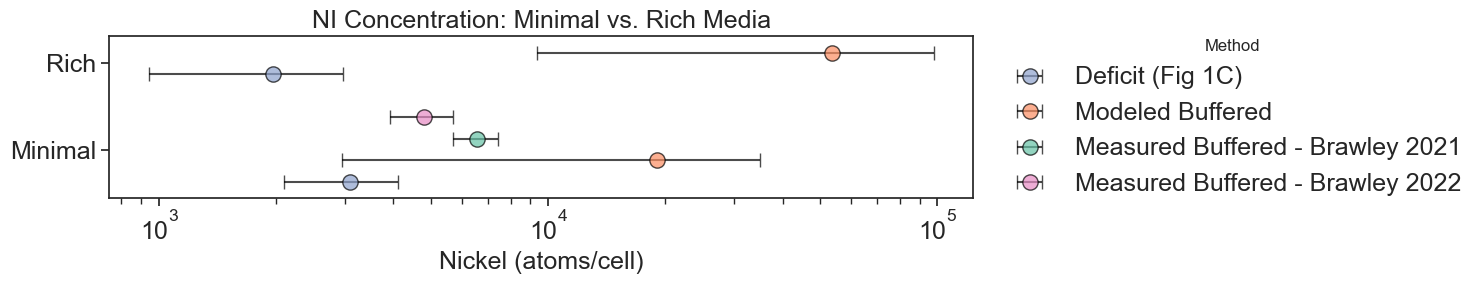

In [43]:
from matplotlib import pyplot as plt

series_order = ["Deficit (Fig 1C)", "Modeled Buffered",
                "Measured Buffered - Brawley 2021", "Measured Buffered - Brawley 2022"]
medium_order  = ["Minimal", "Rich"]

palette_series = {
    "Deficit (Fig 1C)":  "#8da1cc",
    "Modeled Buffered":  "#fc8e62",
    "Measured Buffered - Brawley 2021": "#66c2a6",
    "Measured Buffered - Brawley 2022": "#e78bc4",
}
markers_series = {
    "Minimal":  "o",
    "Rich":  "o",
}

h = 3
fig, ax = plt.subplots(figsize=(15, h))

n_series = len(series_order)

offsets  = {s: 0.3 + (i*(h-1)/5)  for i, s in enumerate(series_order)}


for j, medium in enumerate(medium_order):          # y tick positions: 0, 1
    for series_name in series_order:
        row = df_ni_[
            (df_ni_["medium"]  == medium) &
            (df_ni_["series"]  == series_name)
        ]
        if row.empty:
            continue

        val  = row["y_uM"].values[0]
        err  = row["y_err_uM"].values[0]
        y_pos = (j*(h-0.5*2)) + offsets[series_name]
        print(y_pos)
        ax.errorbar(
            x=val, y=y_pos,
            xerr=err,
            fmt=markers_series[medium],
            alpha=0.7,
            color=palette_series[series_name],
            capsize=5, capthick=1.5, linewidth=1.5,
            ecolor='black',
            markersize=11,
            markeredgecolor="black", markeredgewidth=1,
            label=series_name if j == 0 else "_nolegend_",
        )

ax.set_xscale("log")
ax.set_yticks([0.9, 2.5])
ax.set_ylim(0.0, 3)
ax.set_yticklabels(medium_order, fontsize=18)
ax.set_xlabel("Nickel (atoms/cell)", fontsize=18)
ax.set_ylabel("")
ax.set_title("NI Concentration: Minimal vs. Rich Media", fontsize=18)
ax.tick_params(labelsize=18)
ax.legend(title="Method", frameon=False,
          bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=18)  # legend to the right

plt.tight_layout()
plt.savefig('notebooks/cofactors/buffer_figures/NI_bar_atoms_per_cell.svg', )
plt.show()